# (샘플) 이미지크롤링

In [22]:
import requests
import re
import json
from PIL import Image

In [14]:
def search_images_ddg(key,max_n=200):
    """Search for 'key' with DuckDuckGo and return a unique urls of 'max_n' images
       (Adopted from https://github.com/deepanprabhu/duckduckgo-images-api)
    """
    url        = 'https://duckduckgo.com/'
    params     = {'q':key}
    res        = requests.post(url,data=params)
    searchObj  = re.search(r'vqd=([\d-]+)\&',res.text)
    if not searchObj: print('Token Parsing Failed !'); return
    requestUrl = url + 'i.js'
    headers    = {'User-Agent': 'Mozilla/5.0 (X11; Ubuntu; Linux x86_64; rv:71.0) Gecko/20100101 Firefox/71.0'}
    params     = (('l','us-en'),('o','json'),('q',key),('vqd',searchObj.group(1)),('f',',,,'),('p','1'),('v7exp','a'))
    urls       = []
    while True:
        try:
            res  = requests.get(requestUrl,headers=headers,params=params)
            data = json.loads(res.text)
            for obj in data['results']:
                urls.append(obj['image'])
                max_n = max_n - 1
                if max_n < 1: return list(set(urls))     # dedupe
            if 'next' not in data: return list(set(urls))
            requestUrl = url + data['next']
        except:
            pass

In [19]:
hynn_lst = search_images_ddg('hynn',max_n=5)

In [21]:
hynn_lst[0]

'https://kpopwiki.org/wp-content/uploads/2020/11/EOVAtLgWoAASUI1.jpg'

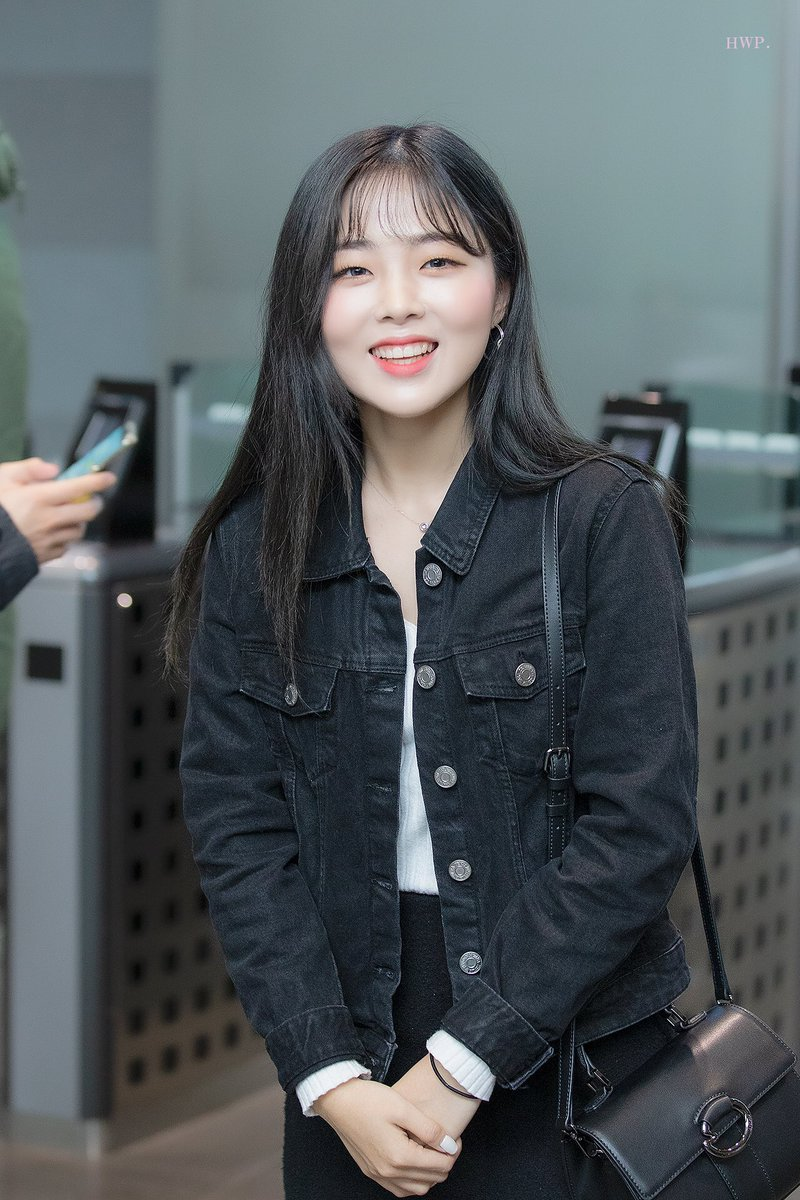

In [37]:
img=Image.open(Image.io.BytesIO(requests.get(hynn_lst[0]).content))
img